## Import ibrary yang dibutuhkan

In [ ]:
!pip install scipy
!pip install scikit-learn

In [ ]:
!pip install tsfel librosa pandas numpy scipy streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.8 MB/s eta 0:00:00


In [ ]:
# Hapus instalasi lama dan instal ulang versi terbaru
!pip uninstall -y tsfel
!pip install --upgrade --force-reinstall tsfel numpy pandas scipy librosa soundfile

Found existing installation: tsfel 0.2.0
Uninstalling tsfel-0.2.0:
  Successfully uninstalled tsfel-0.2.0
  Using cached tsfel-0.2.0-py3-none-any.whl.metadata (9.4 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.4 MB/s eta 0:00:00
  Using cached jedi-0.19.2-py2.py3-none-any.whl.metadata (22 kB)
Using cached tsfel-0.2.0-py3-none-any.whl (63 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.6/219.6 kB 17.7 MB/s eta 0:00:00
 

## Ekstrak audio menjadi fitur statistik

In [ ]:
import tsfel
import librosa
import numpy as np
import pandas as pd
import io
from google.colab import files # For file upload in Colab
from IPython.display import display # For displaying DataFrames nicely

# --- 1. Dapatkan Konfigurasi TSFEL (Cukup Sekali) ---
# Kita pindahkan ini ke luar loop agar tidak diulang-ulang
try:
    cfg_statistical = tsfel.get_features_by_domain("statistical")
    num_features = len(cfg_statistical.get("statistical", {}))
    print(f"✅ Konfigurasi TSFEL untuk {num_features} Fitur Statistik (Domain 'statistical') berhasil dimuat.")
except Exception as e:
    print(f"❌ Gagal memuat konfigurasi TSFEL: {e}")
    # Jika konfigurasi gagal, kita hentikan
    cfg_statistical = None

# List kosong untuk menampung semua DataFrame hasil
all_features_list = []

if cfg_statistical: # Hanya lanjut jika konfigurasi berhasil dimuat
    # --- 2. Upload File (Bisa lebih dari 1) ---
    print("\nSilakan unggah file MP3 Anda (bisa pilih lebih dari satu)...")
    uploaded = files.upload()

    # --- 3. Proses Setiap File yang Diunggah ---
    if uploaded:
        print(f"\n--- Memulai pemrosesan {len(uploaded)} file ---")

        # Loop (iterasi) melalui setiap file yang diunggah
        # uploaded.items() memberikan kita nama file dan kontennya
        for file_name, file_content in uploaded.items():

            print(f"\n⏳ Memproses file: {file_name}...")

            signal = None
            sampling_rate = None

            try:
                # Masukkan byte konten file ke io.BytesIO
                audio_bytes = io.BytesIO(file_content)

                # --- Baca Sinyal Audio ---
                signal, sampling_rate = librosa.load(audio_bytes, sr=None, mono=True)
                print(f"  ✅ Audio '{file_name}' berhasil dimuat (Durasi: {len(signal)/sampling_rate:.2f} d, SR: {sampling_rate} Hz)")

                # --- Ekstraksi Fitur ---
                # window_size=len(signal) untuk mendapatkan 1 set fitur global
                statistical_features_df = tsfel.time_series_features_extractor(
                    cfg_statistical,
                    signal,
                    fs=sampling_rate,
                    window_size=len(signal)
                )

                # --- PENTING: Tambahkan nama file ke DataFrame ---
                # Ini agar kita tahu baris ini milik file mana
                statistical_features_df['filename'] = file_name

                # --- Kumpulkan hasil ---
                all_features_list.append(statistical_features_df)
                print(f"  ✅ Fitur untuk '{file_name}' berhasil diekstrak.")

            except Exception as e:
                # Jika 1 file error, cetak errornya dan lanjut ke file berikutnya
                print(f"  ❌ GAGAL memproses file {file_name}: {e}")

        # --- 4. Gabungkan Semua Hasil dan Simpan ke CSV ---
        if all_features_list:
            print("\n--- Pemrosesan Selesai ---")

            # Gabungkan semua DataFrame (yang ada di list) menjadi satu
            final_combined_df = pd.concat(all_features_list, ignore_index=True)

            # Pindahkan kolom 'filename' ke paling depan agar mudah dibaca
            cols = ['filename'] + [col for col in final_combined_df.columns if col != 'filename']
            final_combined_df = final_combined_df[cols]

            print("\n--- Hasil Gabungan Fitur (Semua File) ---")
            display(final_combined_df)
            # Shape akan menjadi (jumlah_file, jumlah_fitur + 1)
            print(f"Shape of final features DataFrame (files, features+1): {final_combined_df.shape}")

            # --- 5. Simpan ke CSV dan Download ---
            output_filename = 'all_audio_tutup_statistical_features.csv'
            final_combined_df.to_csv(output_filename, index=False)

            print(f"\n✅ Hasil gabungan telah disimpan ke '{output_filename}'.")


        else:
            print("\n⚠️ Tidak ada file yang berhasil diproses.")
    else:
        print("Tidak ada file yang diunggah.")

✅ Konfigurasi TSFEL untuk 20 Fitur Statistik (Domain 'statistical') berhasil dimuat.

Silakan unggah file MP3 Anda (bisa pilih lebih dari satu)...


Saving Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav
Saving Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68egl2kp.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68egl2kp.ingestion-6d56d7dc5b-4mhbr.wav
Saving Tutup.68egl9cu.ingestion-6d56d7dc5b-4nxks.wav to Tutup.68egl9cu.ingestion-6d56d7dc5b-4nxks.wav
Saving Tutup.68egl646.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egl646.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68eglcql.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68eglcql.ingestion-6d56d7dc5b-4mhbr.wav
Saving Tutup.68eglg5g.ingestion-6d56d7dc5b-4nxks.wav to Tutup.68eglg5g.ingestion-6d56d7dc5b-4nxks.wav
Saving Tutup.68eglja2.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68eglja2.ingestion-6

  ✅ Fitur untuk 'Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav...
  ✅ Audio 'Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav' berhasil dimuat (Durasi: 1.88 d, SR: 16000 Hz)


  ✅ Fitur untuk 'Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav...
  ✅ Audio 'Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav' berhasil dimuat (Durasi: 1.71 d, SR: 16000 Hz)


  ✅ Fitur untuk 'Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav...
  ✅ Audio 'Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav' berhasil dimuat (Durasi: 1.79 d, SR: 16000 Hz)


...

  ✅ Fitur untuk 'Tutup.68eguoq2.ingestion-6d56d7dc5b-4nxks.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav...
  ✅ Audio 'Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav' berhasil dimuat (Durasi: 2.00 d, SR: 16000 Hz)


  ✅ Fitur untuk 'Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68eguvdb.ingestion-6d56d7dc5b-4nxks.wav...
  ✅ Audio 'Tutup.68eguvdb.ingestion-6d56d7dc5b-4nxks.wav' berhasil dimuat (Durasi: 2.00 d, SR: 16000 Hz)


  ✅ Fitur untuk 'Tutup.68eguvdb.ingestion-6d56d7dc5b-4nxks.wav' berhasil diekstrak.

--- Pemrosesan Selesai ---

--- Hasil Gabungan Fitur (Semua File) ---


,filename,0_Absolute energy,0_Average power,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,0_ECDF_0,0_ECDF_1,0_ECDF_2,...,0_Mean,0_Mean absolute deviation,0_Median,0_Median absolute deviation,0_Min,0_Peak to peak distance,0_Root mean square,0_Skewness,0_Standard deviation,0_Variance
0,Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav,1476.197500,823.799658,5734.0,22937.0,-0.015594,0.020416,0.000035,0.000070,0.000105,...,0.000574,0.099632,0.000061,0.005280,-0.998749,1.997711,0.226905,-0.275034,0.226904,0.051485
1,Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav,1292.756922,688.643986,6007.0,24029.0,-0.001160,0.001556,0.000033,0.000067,0.000100,...,-0.000479,0.076397,0.000092,0.000916,-0.999207,1.998230,0.207458,-0.283301,0.207457,0.043039
2,Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav,1342.853486,786.847425,5461.0,21845.0,-0.003662,0.004852,0.000037,0.000073,0.000110,...,0.000296,0.086429,0.000031,0.002533,-0.999176,1.998077,0.221757,-0.192225,0.221757,0.049176
3,Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav,1071.694684,598.064768,5734.0,22937.0,-0.000427,0.000519,0.000035,0.000070,0.000105,...,0.001268,0.070629,0.000000,0.000336,-0.982544,1.965424,0.193333,-0.258363,0.193329,0.037376
4,Tutup.68egl2kp.ingestion-6d56d7dc5b-4mhbr.wav,753.438950,383.893485,6280.0,25122.0,-0.001648,0.002136,0.000032,0.000064,0.000096,...,0.000294,0.057486,0.000000,0.001038,-0.806335,1.610199,0.154895,-0.285496,0.154895,0.023992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Tutup.68eguib5.ingestion-6d56d7dc5b-4nxks.wav,13.926305,7.095754,6280.0,25122.0,-0.000122,0.000122,0.000032,0.000064,0.000096,...,0.000013,0.007597,0.000000,0.000092,-0.109833,0.227234,0.021059,0.645825,0.021059,0.000443
96,Tutup.68egulo9.ingestion-6d56d7dc5b-4mhbr.wav,30.640608,15.320783,6400.0,25600.0,-0.000153,0.000153,0.000031,0.000063,0.000094,...,-0.000087,0.010728,0.000000,0.000092,-0.147552,0.344452,0.030944,0.588136,0.030944,0.000958
97,Tutup.68eguoq2.ingestion-6d56d7dc5b-4nxks.wav,39.287428,19.644328,6400.0,25600.0,-0.000397,0.000397,0.000031,0.000063,0.000094,...,-0.000087,0.012994,0.000000,0.000214,-0.165131,0.356873,0.035039,0.632659,0.035039,0.001228
98,Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav,42.714039,21.357687,6400.0,25600.0,-0.000336,0.000275,0.000031,0.000063,0.000094,...,-0.000003,0.013503,0.000000,0.000153,-0.185852,0.389954,0.036535,0.629731,0.036535,0.001335


Shape of final features DataFrame (files, features+1): (100, 32)

✅ Hasil gabungan telah disimpan ke 'all_audio_tutup_statistical_features.csv'.


## Menampilkan Data

In [3]:
import pandas as pd
from IPython.display import display
import os # Untuk mengecek apakah file ada

# --- 1. Tentukan Nama File ---
# !!! PERHATIAN:
# Anda menulis 'buka' dua kali di prompt.
# Saya asumsikan file kedua seharusnya 'tutup'.
# Ganti nama file ini jika asumsi saya salah.
file_buka = 'all_audio_buka_statistical_features.csv'
file_tutup = 'all_audio_tutup_statistical_features.csv'

list_dataframes = []

# --- 2. Muat dan beri label data 'buka' ---
try:
    if os.path.exists(file_buka):
        df_buka = pd.read_csv(file_buka)
        df_buka['label'] = 'buka' # Tambahkan kolom label
        list_dataframes.append(df_buka)
        print(f"✅ Berhasil memuat '{file_buka}' (Total: {df_buka.shape[0]} baris data 'buka')")
    else:
        print(f"❌ GAGAL: File '{file_buka}' tidak ditemukan.")

except Exception as e:
    print(f"❌ Error saat membaca {file_buka}: {e}")

# --- 3. Muat dan beri label data 'tutup' ---
try:
    if os.path.exists(file_tutup):
        df_tutup = pd.read_csv(file_tutup)
        df_tutup['label'] = 'tutup' # Tambahkan kolom label
        list_dataframes.append(df_tutup)
        print(f"✅ Berhasil memuat '{file_tutup}' (Total: {df_tutup.shape[0]} baris data 'tutup')")
    else:
        print(f"❌ GAGAL: File '{file_tutup}' tidak ditemukan.")

except Exception as e:
    print(f"❌ Error saat membaca {file_tutup}: {e}")

# --- 4. Gabungkan dan Tampilkan ---
if len(list_dataframes) == 2: # Hanya jika KEDUA file berhasil dimuat

    # Gabungkan kedua DataFrame menjadi satu
    df_combined = pd.concat(list_dataframes, ignore_index=True)

    # Pindahkan kolom 'label' ke depan (setelah 'filename') agar mudah dibaca
    try:
        # Dapatkan semua kolom
        cols = list(df_combined.columns)
        # Hapus 'label' dari akhir
        cols.remove('label')
        # Masukkan 'label' di posisi kedua (setelah 'filename')
        cols.insert(1, 'label')
        # Terapkan urutan kolom baru
        df_combined = df_combined[cols]
    except Exception as e:
        print(f"Info: Tidak dapat mengatur ulang urutan kolom. Error: {e}")

    print("\n--- Hasil Gabungan Dataset dengan Label ---")
    display(df_combined)

    print("\n--- Ringkasan Dataset ---")
    print(f"Total baris data: {df_combined.shape[0]}")
    print("Distribusi Label:")
    print(df_combined['label'].value_counts())

elif len(list_dataframes) == 1:
    print("\n⚠️ Hanya 1 dari 2 file yang ditemukan. Menampilkan data yang ada saja:")
    display(list_dataframes[0])
else:
    print("\n⚠️ Tidak ada file CSV yang ditemukan. Tidak ada data untuk digabungkan.")

✅ Berhasil memuat 'all_audio_buka_statistical_features.csv' (Total: 100 baris data 'buka')
✅ Berhasil memuat 'all_audio_tutup_statistical_features.csv' (Total: 100 baris data 'tutup')

--- Hasil Gabungan Dataset dengan Label ---


,filename,label,0_Absolute energy,0_Average power,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,0_ECDF_0,0_ECDF_1,...,0_Mean,0_Mean absolute deviation,0_Median,0_Median absolute deviation,0_Min,0_Peak to peak distance,0_Root mean square,0_Skewness,0_Standard deviation,0_Variance
0,Buka.68ef9e8r.ingestion-6d56d7dc5b-5ffk6.wav,buka,1846.499066,1846.614479,3200.0,12800.0,-0.120514,0.161865,0.000063,0.000125,...,0.001541,0.212731,0.000580,0.077988,-0.999359,1.998749,0.339715,-0.355125,0.339711,0.115404
1,Buka.68ef9e8r.wav.68egbh60.ingestion-6d56d7dc5...,buka,1846.499066,1846.614479,3200.0,12800.0,-0.120514,0.161865,0.000063,0.000125,...,0.001541,0.212731,0.000580,0.077988,-0.999359,1.998749,0.339715,-0.355125,0.339711,0.115404
2,Buka.68ef9f04.ingestion-6d56d7dc5b-4nxks.wav,buka,423.226522,423.252976,3200.0,12800.0,-0.003784,0.034698,0.000063,0.000125,...,0.000287,0.079750,0.000092,0.003143,-0.822021,1.321320,0.162640,-1.135462,0.162639,0.026452
3,Buka.68ef9lcr.ingestion-6d56d7dc5b-4mhbr.wav,buka,370.033057,370.056185,3200.0,12800.0,-0.013123,0.013580,0.000063,0.000125,...,0.000073,0.070370,0.000000,0.002716,-0.969940,1.686218,0.152076,-0.740073,0.152076,0.023127
4,Buka.68ef9lcr.wav.68egbhii.ingestion-6d56d7dc5...,buka,370.033057,370.056185,3200.0,12800.0,-0.013123,0.013580,0.000063,0.000125,...,0.000073,0.070370,0.000000,0.002716,-0.969940,1.686218,0.152076,-0.740073,0.152076,0.023127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Tutup.68eguib5.ingestion-6d56d7dc5b-4nxks.wav,tutup,13.926305,7.095754,6280.0,25122.0,-0.000122,0.000122,0.000032,0.000064,...,0.000013,0.007597,0.000000,0.000092,-0.109833,0.227234,0.021059,0.645825,0.021059,0.000443
196,Tutup.68egulo9.ingestion-6d56d7dc5b-4mhbr.wav,tutup,30.640608,15.320783,6400.0,25600.0,-0.000153,0.000153,0.000031,0.000063,...,-0.000087,0.010728,0.000000,0.000092,-0.147552,0.344452,0.030944,0.588136,0.030944,0.000958
197,Tutup.68eguoq2.ingestion-6d56d7dc5b-4nxks.wav,tutup,39.287428,19.644328,6400.0,25600.0,-0.000397,0.000397,0.000031,0.000063,...,-0.000087,0.012994,0.000000,0.000214,-0.165131,0.356873,0.035039,0.632659,0.035039,0.001228
198,Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav,tutup,42.714039,21.357687,6400.0,25600.0,-0.000336,0.000275,0.000031,0.000063,...,-0.000003,0.013503,0.000000,0.000153,-0.185852,0.389954,0.036535,0.629731,0.036535,0.001335



--- Ringkasan Dataset ---
Total baris data: 200
Distribusi Label:
label
buka     100
tutup    100
Name: count, dtype: int64


--- 1. Analisis Nilai Kosong (Missing Values) ---
✅ Tidak ada nilai kosong (missing values) di dalam dataset.


--- 2. Deteksi Outlier (Local Outlier Factor) ---

✅ LOF Selesai. Ditemukan 20 outlier (dari 200 data bersih).
--- Daftar Data Outlier (Paling Aneh Teratas) ---


,filename,label,lof_score
12,Buka.68efb3pd.ingestion-6d56d7dc5b-5ffk6.wav,buka,-3.464832
13,Buka.68efb3pd.wav.68egbjdl.ingestion-6d56d7dc5...,buka,-3.464832
7,Buka.68ef9rmf.ingestion-6d56d7dc5b-4mhbr.wav,buka,-3.462228
11,Buka.68efa1bn.wav.68egbio1.ingestion-6d56d7dc5...,buka,-3.426166
10,Buka.68efa1bn.ingestion-6d56d7dc5b-4mhbr.wav,buka,-3.426166
8,Buka.68ef9utt.ingestion-6d56d7dc5b-5ffk6.wav,buka,-3.425238
9,Buka.68ef9utt.wav.68egbibh.ingestion-6d56d7dc5...,buka,-3.425238
167,Tutup.68egrojj.ingestion-6d56d7dc5b-5ffk6.wav,tutup,-3.356841
1,Buka.68ef9e8r.wav.68egbh60.ingestion-6d56d7dc5...,buka,-3.094002
0,Buka.68ef9e8r.ingestion-6d56d7dc5b-5ffk6.wav,buka,-3.094002



Membuat visualisasi PCA 2D dari Outlier...


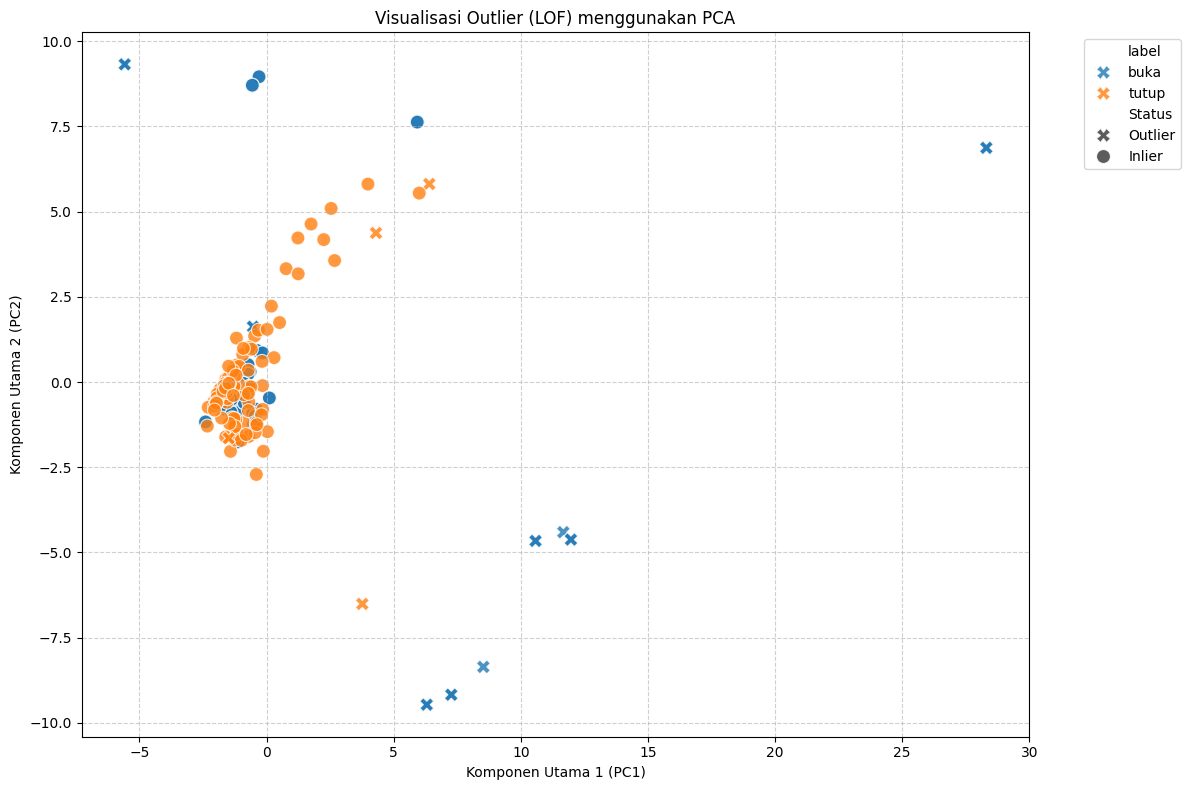

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

# Pastikan variabel df_combined ada dari sel sebelumnya
if 'df_combined' in locals() and not df_combined.empty:

    print("--- 1. Analisis Nilai Kosong (Missing Values) ---")

    # Hitung nilai kosong per kolom
    missing_values = df_combined.isnull().sum()

    # Tampilkan HANYA kolom yang punya nilai kosong
    missing_data_cols = missing_values[missing_values > 0]

    if missing_data_cols.empty:
        print("✅ Tidak ada nilai kosong (missing values) di dalam dataset.\n")
    else:
        print("Kolom berikut memiliki nilai kosong:")
        print(missing_data_cols)

        # Visualisasikan pola nilai kosong dengan heatmap
        plt.figure(figsize=(15, 6))
        sns.heatmap(df_combined.isnull(), cbar=False, cmap='viridis', yticklabels=False)
        plt.title('Pola Nilai Kosong (Kuning = Hilang)')
        plt.show()

    # --- 2. Deteksi Outlier dengan Local Outlier Factor (LOF) ---

    print("\n--- 2. Deteksi Outlier (Local Outlier Factor) ---")

    # LOF hanya bisa berjalan pada data numerik
    # Kita pisahkan kolom non-numerik (filename, label)
    non_numeric_cols = ['filename', 'label']

    # Ambil semua kolom yang numerik
    numerical_features = [col for col in df_combined.columns if col not in non_numeric_cols]

    # Buat salinan data numerik
    X = df_combined[numerical_features].copy()

    # PENTING: LOF tidak bisa menangani data kosong.
    # Kita harus mengatasinya dulu. Cara termudah adalah menghapus baris yang kosong.
    # (Alternatif lain adalah imputasi, tapi drop lebih aman untuk deteksi outlier)

    # Simpan indeks asli sebelum di-drop
    original_indices = X.index

    # Drop baris yang punya NaN
    X_cleaned = X.dropna()

    # Catat berapa data yang di-drop
    rows_dropped = len(original_indices) - len(X_cleaned)
    if rows_dropped > 0:
        print(f"⚠️ Peringatan: {rows_dropped} baris dihapus karena mengandung nilai kosong sebelum menjalankan LOF.")

    if X_cleaned.empty:
        print("❌ GAGAL: Tidak ada data tersisa setelah menghapus nilai kosong. Tidak bisa menjalankan LOF.")
    else:
        # a. Scaling Data
        # LOF sensitif terhadap skala, jadi kita perlu menstandarisasi data
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_cleaned)

        # b. Inisialisasi dan Terapkan LOF
        # n_neighbors=20 adalah nilai umum, contamination=0.1 berarti kita asumsikan 10% data adalah outlier
        lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
        y_pred_lof = lof.fit_predict(X_scaled)

        # LOF akan memberi label -1 untuk outlier dan 1 untuk inlier
        # Dapatkan skor outliernya (semakin kecil/negatif, semakin outlier)
        lof_scores = lof.negative_outlier_factor_

        # Masukkan hasil LOF kembali ke DataFrame yang sudah bersih
        # Kita gunakan .loc untuk memastikan indeksnya cocok
        df_cleaned = df_combined.loc[X_cleaned.index].copy()
        df_cleaned['lof_score'] = lof_scores
        df_cleaned['is_outlier_lof'] = y_pred_lof

        # c. Tampilkan data yang terdeteksi sebagai outlier
        outliers_df = df_cleaned[df_cleaned['is_outlier_lof'] == -1].sort_values(by='lof_score')

        print(f"\n✅ LOF Selesai. Ditemukan {len(outliers_df)} outlier (dari {len(df_cleaned)} data bersih).")

        if not outliers_df.empty:
            print("--- Daftar Data Outlier (Paling Aneh Teratas) ---")
            # Tampilkan 10 outlier teratas
            display(outliers_df.head(10)[['filename', 'label', 'lof_score']])

        # d. Visualisasi Outlier
        # Karena kita punya 40+ fitur, kita tidak bisa memplotnya langsung.
        # Kita gunakan PCA untuk mengurangi dimensi jadi 2D agar bisa digambar.
        print("\nMembuat visualisasi PCA 2D dari Outlier...")

        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)

        # Buat DataFrame untuk plot
        df_plot = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
        df_plot['label'] = df_cleaned['label']
        # Ubah -1 (outlier) dan 1 (inlier) menjadi teks agar legenda lebih jelas
        df_plot['Status'] = np.where(df_cleaned['is_outlier_lof'] == -1, 'Outlier', 'Inlier')


        # Buat Scatter Plot
        plt.figure(figsize=(12, 8))
        sns.scatterplot(
            data=df_plot,
            x='PC1',
            y='PC2',
            hue='label',      # Warna berdasarkan label (buka/tutup)
            style='Status',   # Bentuk berdasarkan status (outlier/inlier)
            markers={'Inlier': 'o', 'Outlier': 'X'}, # Outlier ditandai 'X'
            s=100,            # Ukuran penanda
            alpha=0.8
        )
        plt.title('Visualisasi Outlier (LOF) menggunakan PCA')
        plt.xlabel('Komponen Utama 1 (PC1)')
        plt.ylabel('Komponen Utama 2 (PC2)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

else:
    print("❌ GAGAL: Variabel 'df_combined' tidak ditemukan atau kosong. Harap jalankan sel kode sebelumnya terlebih dahulu.")

--- 1. Mempersiapkan Data (Menangani Missing Values) ---
✅ Nilai kosong (NaN) telah diisi menggunakan nilai rata-rata (mean).

--- 2. Normalisasi Data (Menggunakan RobustScaler) ---
✅ Data telah dinormalisasi menggunakan RobustScaler.
   (Skala data kini terpusat di median dan tahan terhadap outlier)

--- 3. Visualisasi Data Setelah Normalisasi ---
Membuat Box Plot untuk 40+ Fitur...
(Ini menunjukkan bahwa semua fitur sekarang berada pada skala yang sebanding)


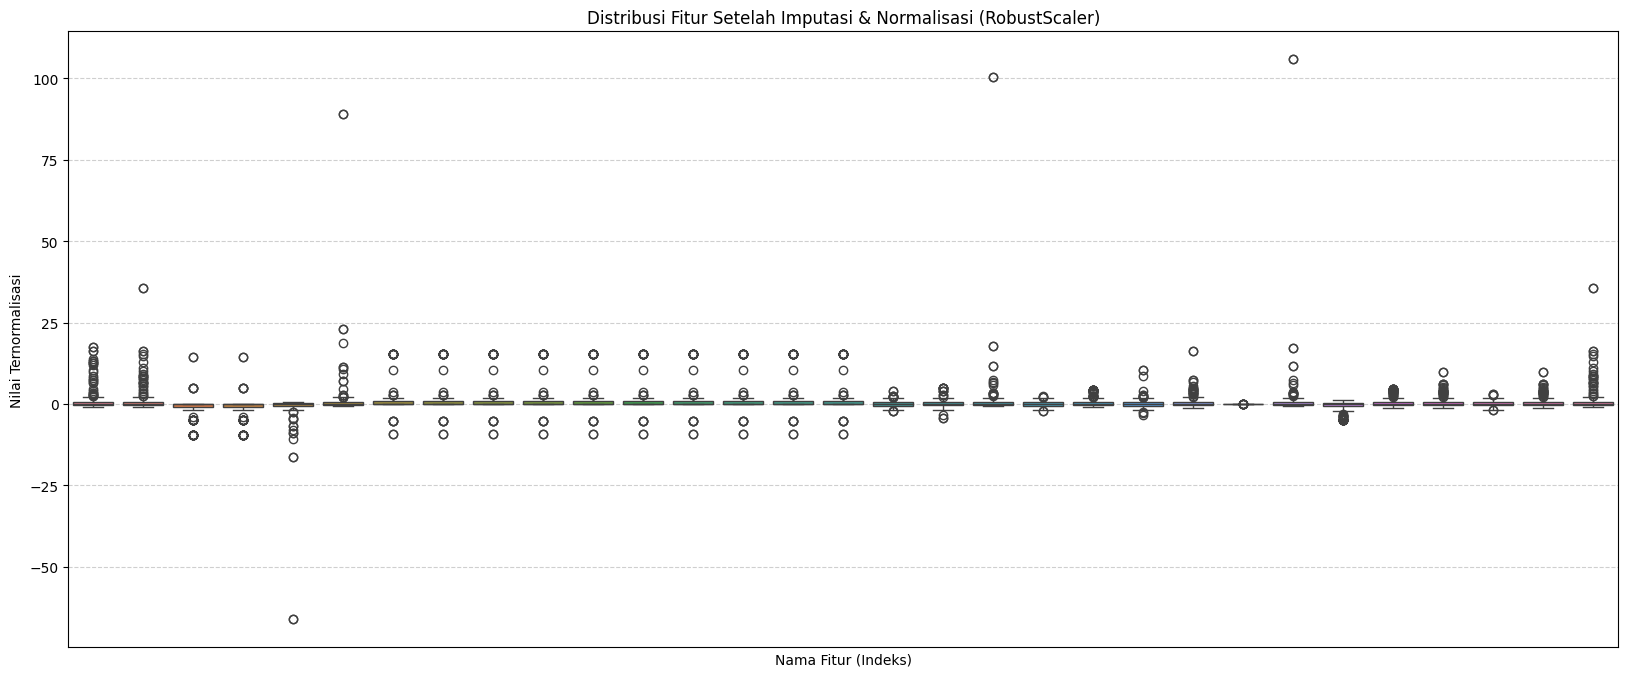


Membuat visualisasi PCA 2D dari data yang sudah bersih...


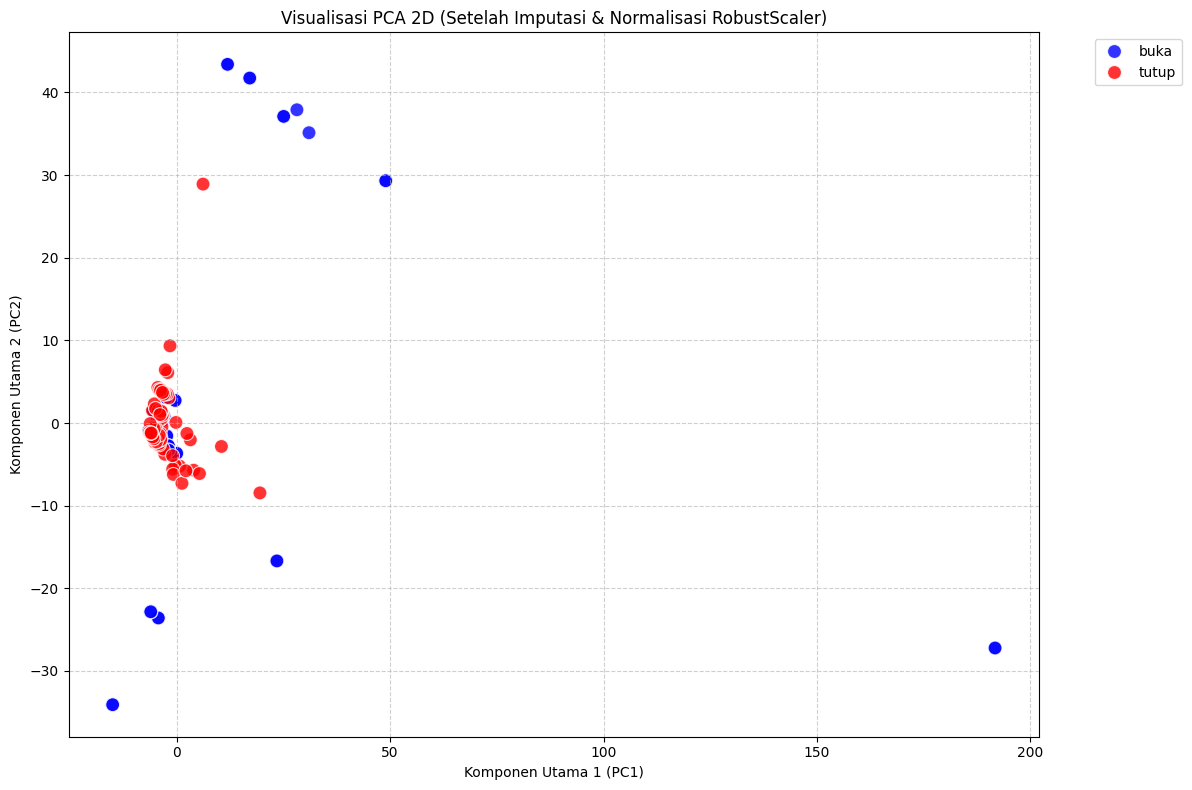

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from IPython.display import display

# Pastikan variabel df_combined ada dari sel sebelumnya
if 'df_combined' in locals() and not df_combined.empty:

    print("--- 1. Mempersiapkan Data (Menangani Missing Values) ---")

    # Pisahkan kolom non-numerik (label, filename)
    non_numeric_cols = ['filename', 'label']
    numeric_cols = [col for col in df_combined.columns if col not in non_numeric_cols]

    # Buat salinan data agar data asli tetap aman
    df_processed = df_combined.copy()

    # --- Gunakan SimpleImputer untuk mengisi nilai NaN ---
    # Kita gunakan strategi 'mean' (nilai rata-rata)
    imputer = SimpleImputer(strategy='mean')

    # Terapkan imputer HANYA pada kolom numerik
    df_processed[numeric_cols] = imputer.fit_transform(df_processed[numeric_cols])

    print("✅ Nilai kosong (NaN) telah diisi menggunakan nilai rata-rata (mean).\n")

    # -----------------------------------------------------------------

    print("--- 2. Normalisasi Data (Menggunakan RobustScaler) ---")

    # Gunakan RobustScaler. Scaler ini tahan (robust) terhadap outlier.
    # Scaler ini akan mengurangi median dan menskalakan data berdasarkan
    # rentang interkuartil (IQR), sehingga outlier tidak memengaruhi skala.
    scaler = RobustScaler()

    # Terapkan scaler HANYA pada kolom numerik
    df_processed[numeric_cols] = scaler.fit_transform(df_processed[numeric_cols])

    print("✅ Data telah dinormalisasi menggunakan RobustScaler.")
    print("   (Skala data kini terpusat di median dan tahan terhadap outlier)\n")

    # -----------------------------------------------------------------

    print("--- 3. Visualisasi Data Setelah Normalisasi ---")

    # --- Visualisasi A: Box Plot (Bukti Normalisasi) ---
    print("Membuat Box Plot untuk 40+ Fitur...")
    print("(Ini menunjukkan bahwa semua fitur sekarang berada pada skala yang sebanding)")

    plt.figure(figsize=(20, 8))
    # Plot boxplot dari SEMUA fitur numerik
    sns.boxplot(data=df_processed[numeric_cols])
    plt.title('Distribusi Fitur Setelah Imputasi & Normalisasi (RobustScaler)')
    plt.xlabel('Nama Fitur (Indeks)')
    plt.ylabel('Nilai Ternormalisasi')
    # Sembunyikan label x karena terlalu banyak (40+)
    plt.xticks([])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # --- Visualisasi B: PCA Plot (Hasil Klasterisasi) ---
    print("\nMembuat visualisasi PCA 2D dari data yang sudah bersih...")

    # Jalankan PCA pada data yang sudah bersih dan ternormalisasi
    pca = PCA(n_components=2)

    # Ambil data numerik yang sudah diproses
    X_normalized = df_processed[numeric_cols]

    # Terapkan PCA
    X_pca_normalized = pca.fit_transform(X_normalized)

    # Buat DataFrame untuk plot
    df_plot_normalized = pd.DataFrame(data=X_pca_normalized, columns=['PC1', 'PC2'], index=df_processed.index)
    # Tambahkan kembali label untuk pewarnaan
    df_plot_normalized['label'] = df_processed['label']

    # Buat Scatter Plot
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_plot_normalized,
        x='PC1',
        y='PC2',
        hue='label',  # Warna berdasarkan label (buka/tutup)
        s=100,
        alpha=0.8,
        palette={'buka': 'blue', 'tutup': 'red'} # Tentukan warna
    )
    plt.title('Visualisasi PCA 2D (Setelah Imputasi & Normalisasi RobustScaler)')
    plt.xlabel('Komponen Utama 1 (PC1)')
    plt.ylabel('Komponen Utama 2 (PC2)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

else:
    print("❌ GAGAL: Variabel 'df_combined' tidak ditemukan atau kosong. Harap jalankan sel kode sebelumnya terlebih dahulu.")

--- 1. Memuat Dataset (Minimal 'buka' dan 'tutup') ---
✅ Berhasil memuat 'all_audio_buka_statistical_features.csv' (Total: 100 baris)
✅ Berhasil memuat 'all_audio_tutup_statistical_features.csv' (Total: 100 baris)
⚠️ INFO: File opsional 'all_audio_unknown_statistical_features.csv' tidak ditemukan. Model akan dilatih sebagai 2-kelas (buka/tutup).

--- 2. Model akan dilatih dengan 2 kelas ---
Distribusi Data (Sebelum SMOTE):
label
buka     100
tutup    100
Name: count, dtype: int64

--- 3. Mengisi nilai kosong (NaN) menggunakan 'mean' ---

--- 4. Menjalankan SMOTE untuk menyeimbangkan data latih... ---
Distribusi Data Latih (Setelah SMOTE):
label
buka     80
tutup    80
Name: count, dtype: int64

--- 5. Menjalankan RobustScaler ---

--- 6. Melatih model Random Forest Classifier... ---
✅ Model berhasil dilatih!

--- 7. Hasil dan Akurasi Model (pada Data Uji) ---
   AKURASI MODEL: 87.50 %   

Laporan Klasifikasi (Classification Report):
              precision    recall  f1-score   support

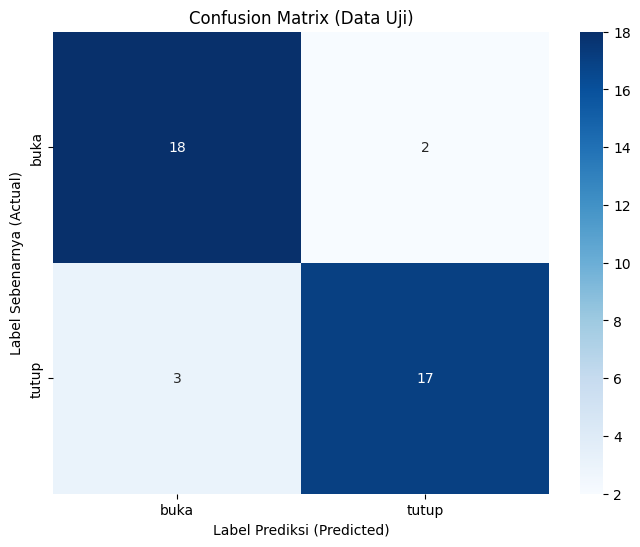


--- 8. Menyimpan 3 file artifact... ---
✅ Model disimpan sebagai 'model_suara_classifier.joblib'
✅ Imputer disimpan sebagai 'imputer.joblib'
✅ Scaler disimpan sebagai 'scaler.joblib'

Harap unggah 3 file .joblib baru ini ke aplikasi Streamlit Anda.


In [8]:
# PERINTAH INSTALASI: Jalankan ini di sel pertama
# !pip install pandas numpy matplotlib seaborn joblib scikit-learn tsfel librosa imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE # <-- IMPORT ALGORITMA PENYEIMBANG
from IPython.display import display
import os

print("--- 1. Memuat Dataset (Minimal 'buka' dan 'tutup') ---")

# --- Tentukan Nama File ---
file_buka = 'all_audio_buka_statistical_features.csv'
file_tutup = 'all_audio_tutup_statistical_features.csv'
file_unknown = 'all_audio_unknown_statistical_features.csv' # <-- DATA BARU (Opsional)

list_dataframes = []
# PERBAIKAN: Flag baru untuk mengecek file wajib
data_wajib_lengkap = True

# --- Muat dan beri label data 'buka' ---
try:
    df_buka = pd.read_csv(file_buka)
    df_buka['label'] = 'buka'
    list_dataframes.append(df_buka)
    print(f"✅ Berhasil memuat '{file_buka}' (Total: {df_buka.shape[0]} baris)")
except FileNotFoundError:
    print(f"❌ GAGAL: File Wajib '{file_buka}' tidak ditemukan.")
    data_wajib_lengkap = False # Set flag error

# --- Muat dan beri label data 'tutup' ---
try:
    df_tutup = pd.read_csv(file_tutup)
    df_tutup['label'] = 'tutup'
    list_dataframes.append(df_tutup)
    print(f"✅ Berhasil memuat '{file_tutup}' (Total: {df_tutup.shape[0]} baris)")
except FileNotFoundError:
    print(f"❌ GAGAL: File Wajib '{file_tutup}' tidak ditemukan.")
    data_wajib_lengkap = False # Set flag error

# --- PERBAIKAN: Muat data 'unknown' (sekarang opsional) ---
try:
    df_unknown = pd.read_csv(file_unknown)
    df_unknown['label'] = 'unknown'
    list_dataframes.append(df_unknown)
    print(f"✅ Berhasil memuat file opsional '{file_unknown}' (Total: {df_unknown.shape[0]} baris)")
except FileNotFoundError:
    # Ini sekarang hanya warning, tidak menghentikan program
    print(f"⚠️ INFO: File opsional '{file_unknown}' tidak ditemukan. Model akan dilatih sebagai 2-kelas (buka/tutup).")

# --- PERBAIKAN: Cek jika minimal 2 file (buka & tutup) berhasil dimuat ---
if data_wajib_lengkap:

    # --- 2. Gabungkan dan Pra-pemrosesan Awal ---
    df_combined = pd.concat(list_dataframes, ignore_index=True)

    print(f"\n--- 2. Model akan dilatih dengan {len(list_dataframes)} kelas ---")
    print("Distribusi Data (Sebelum SMOTE):")
    print(df_combined['label'].value_counts())

    # Pisahkan kolom fitur (X) dan kolom target/label (y)
    non_numeric_cols = ['filename', 'label']
    numeric_cols = [col for col in df_combined.columns if col not in non_numeric_cols]

    X = df_combined[numeric_cols]
    y = df_combined['label']

    # --- 3. Mengisi Nilai Kosong (Imputasi) ---
    # Kita harus mengisi NaN SEBELUM menggunakan SMOTE
    print("\n--- 3. Mengisi nilai kosong (NaN) menggunakan 'mean' ---")
    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(X)
    X = pd.DataFrame(X_imputed, columns=numeric_cols) # Kembalikan ke DataFrame

    # --- 4. Membagi Data: 80% Latih, 20% Uji ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y # Stratify penting untuk data tidak seimbang
    )

    # --- 5. ALGORITMA SMOTE (Penyeimbangan Data) ---
    # SMOTE hanya diterapkan pada data latih (X_train, y_train)
    # Ini untuk mencegah "data leakage"
    print("\n--- 4. Menjalankan SMOTE untuk menyeimbangkan data latih... ---")
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

    print("Distribusi Data Latih (Setelah SMOTE):")
    print(y_train_balanced.value_counts())

    # --- 6. Normalisasi Data (Scaling) ---
    # Kita 'fit' scaler HANYA pada data latih yang sudah seimbang
    print("\n--- 5. Menjalankan RobustScaler ---")
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_balanced)
    # Kita 'transform' data uji menggunakan scaler yang sama
    X_test_scaled = scaler.transform(X_test)

    # --- 7. Melatih Model Klasifikasi ---
    print("\n--- 6. Melatih model Random Forest Classifier... ---")
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train_scaled, y_train_balanced)
    print("✅ Model berhasil dilatih!\n")

    # --- 8. Mengevaluasi Model ---
    print("--- 7. Hasil dan Akurasi Model (pada Data Uji) ---")
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    print("============================================")
    print(f"   AKURASI MODEL: {accuracy * 100:.2f} %   ")
    print("============================================")

    print("\nLaporan Klasifikasi (Classification Report):")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title('Confusion Matrix (Data Uji)')
    plt.ylabel('Label Sebenarnya (Actual)')
    plt.xlabel('Label Prediksi (Predicted)')
    plt.show()

    # --- 9. Menyimpan Model ---
    print("\n--- 8. Menyimpan 3 file artifact... ---")
    joblib.dump(model, 'model_suara_classifier.joblib')
    joblib.dump(imputer, 'imputer.joblib')
    joblib.dump(scaler, 'scaler.joblib')

    print("✅ Model disimpan sebagai 'model_suara_classifier.joblib'")
    print("✅ Imputer disimpan sebagai 'imputer.joblib'")
    print("✅ Scaler disimpan sebagai 'scaler.joblib'")
    print("\nHarap unggah 3 file .joblib baru ini ke aplikasi Streamlit Anda.")

else:
    print("\n❌ GAGAL: Data tidak cukup. Pastikan minimal file 'buka' dan 'tutup' CSV ada di folder yang sama.")


## Evaluasi
dari hasil prediksi semua data bergantung pada fitur statistik sehingga suara tidak menemukan pembeda yang membuat model selalu memprediksi buka

link dataset
https://drive.google.com/drive/folders/16e80DwDgUzjX7d69ZZwuWDMYGxYQM31j?usp=sharing

link website

https://prediksisuara.streamlit.app/